# Compare the effect of different dataset initialisations

In [1]:
from typing import List
import numpy as np
import json
from pydantic import BaseModel
#locals
from configs import get_class_list
from video_dataset import get_wlasl_info, get_labels_path, load_data_from_json
from utils import plt_display_grid, load_rgb_frames_from_video
from video_dataset import get_example_videos
from preprocess import WLASLClass
from stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    get_per_instance_stats,
    plot_distribution,
    sort_distribution,
    HistoGram,
    reverse_preproc_format,
    to_preproc_format,
)

Please update your PyTorchVideo to latest master


## load data

In [2]:
split_idx = 3 #change for different split
split_options: List[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
split_name: AVAIL_SPLITS = split_options[split_idx]
print(f'Selected: {split_name}')
classes = get_class_list()
print(f'Num classes: {len(classes)}')

set_options: List[AVAIL_SETS] = ['train', 'test', 'val']
all_sets = {}

tot = 0
for set_name in set_options:
    set_path_info = get_wlasl_info(split_name, set_name)
    set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
    all_sets[set_name] = reverse_preproc_format(
        load_data_from_json(set_path, policy="strict"),
        classes)
    print(f'Length of {set_name}: {len(all_sets[set_name])}')
    tot += len(all_sets[set_name])
print(f'Total instances: {tot}')

print(all_sets['test'][0]['gloss'])
print(all_sets['test'][0]['instances'][0])


Selected: asl2000
Num classes: 2000
Length of train: 2000
Length of test: 2000
Length of val: 2000
Total instances: 6000
book
bbox=[60, 37, 197, 230] frame_end=78 frame_start=1 instance_id=15 signer_id=49 source='aslpro' split='test' url='http://www.aslpro.com/main/b/book_medicine.swf' variation_id=0 video_id='07092' label_num=0 label_name='book'


### get stats

In [3]:

all_stats = {}

for key, item in all_sets.items():
    all_stats[key] = get_per_instance_stats([WLASLClass.model_validate(i) for i in item])
    


In [4]:
setname: AVAIL_SETS = 'train'
metric = 'num_instances'
print(all_stats[setname][classes[-1]][metric])
print(all_stats[setname][classes[-1]].keys())

5
dict_keys(['num_instances', 'length_distribution', 'signers_distribution', 'source_distribution', 'url_distribution', 'variation_distribution'])


/home/luke/Code/SLR/code/stats.py:488: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


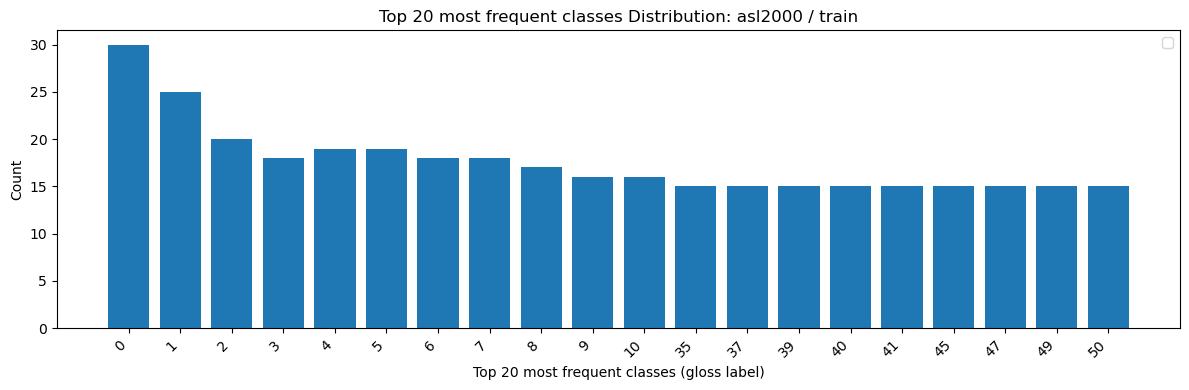

/home/luke/Code/SLR/code/stats.py:488: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


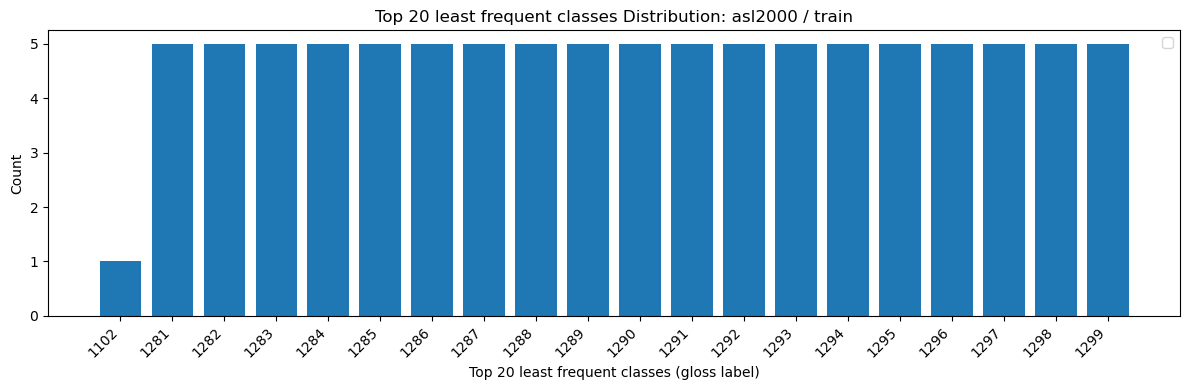

In [5]:
bins = 20
cls_names = list(all_stats[setname].keys())
num_inst_distribution = {cls_names.index(k) : all_stats[setname][k][metric] for k in cls_names}
sorted_num_inst_distribution = sort_distribution(num_inst_distribution)

top_n = list(sorted_num_inst_distribution.items())[-bins:]
bottom_n = list(sorted_num_inst_distribution.items())[:bins]

plot_distribution(
    HistoGram(top_n),
    set_name=setname,
    split_name=split_name,
    metric=f'Top {bins} most frequent classes',
    unit='gloss label',
    categorical=True,
    bins=bins,
    show_nums_on_bars=False
)

plot_distribution(
    HistoGram(bottom_n),
    set_name=setname,
    split_name=split_name,
    metric=f'Top {bins} least frequent classes',
    unit='gloss label',
    categorical=True,
    bins=bins,
    show_nums_on_bars=False
)


In [7]:
bottom_100_label_nums = [i for i, _ in list(sorted_num_inst_distribution.items())[:100]]
bottom_100_label_names = [classes[i] for i in bottom_100_label_nums]

print(bottom_100_label_nums[0])

def _pydantic_default(obj):
    if isinstance(obj, BaseModel):
        return obj.model_dump()

split_name = 'asl100'
new_split_name = 'asl100_bottom'
new_suffix = 'num_instances.json'
for set_name in set_options:
    bottom_100_subset = to_preproc_format(
        all_sets[set_name],
        criterion=lambda x: x['gloss'] in bottom_100_label_names
    )
    original_set_path_info = get_wlasl_info(split_name, set_name)
    new_dir = original_set_path_info['labels'].parent / new_split_name 
    new_dir.mkdir(exist_ok=True, parents=True)
    new_path = new_dir / f'{set_name}_{new_suffix}'
    
    with open(new_path, 'w') as f:
        json.dump(bottom_100_subset, f, indent=2, default=_pydantic_default)
    print(f'Saved to: {new_path}')

1102
Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/train_num_instances.json
Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/test_num_instances.json
Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/val_num_instances.json


In [ ]:
cls_idx = 1102
print(len(all_sets[setname][cls_idx]['instances']))
ex_vids = get_example_videos(
    instances=all_sets[setname][cls_idx]['instances'],)
print(ex_vids)

1
[PosixPath('../data/WLASL/WLASL2000/19055.mp4')]


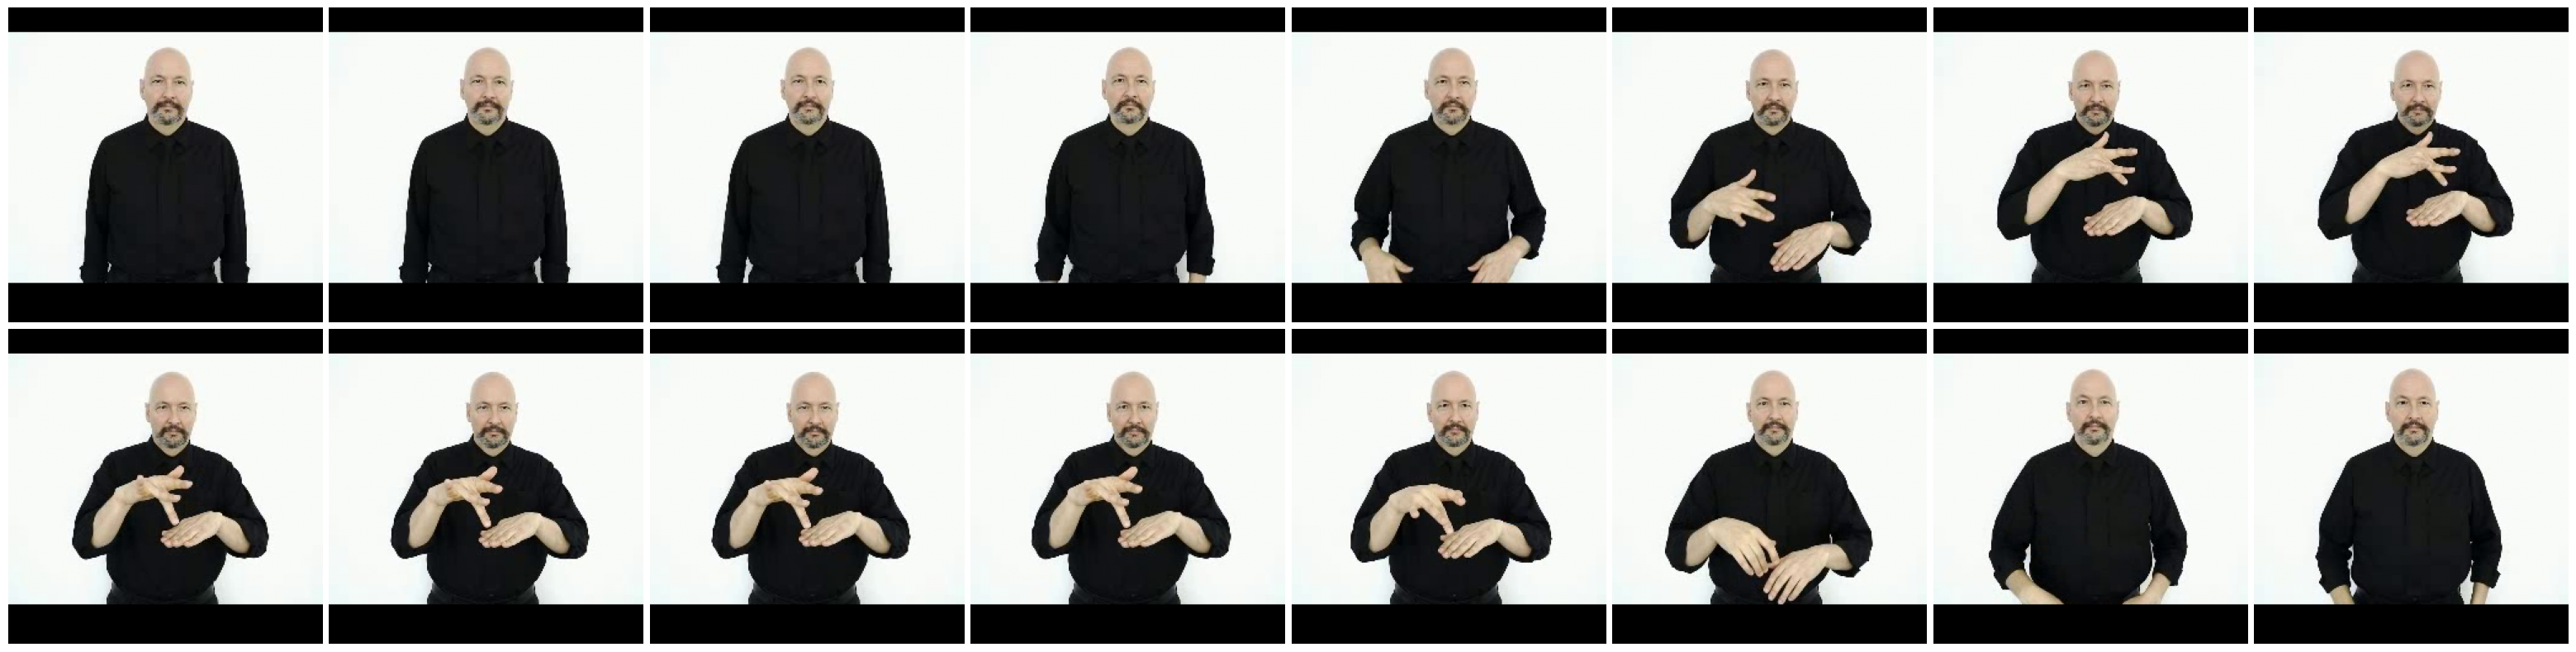

In [ ]:
for e in ex_vids:
    plt_display_grid(
    load_rgb_frames_from_video(e, 0, 0 , all=True),
    16,
)

In [ ]:
split_dist = {}
def printv(msg = '', verbose: bool = False):
    if verbose:
        print(msg)
        
for split_name in split_options:
    printv(f'Analyzing split: {split_name}')
    printv('-'*50)
    tot = 0
    all_stats = {}
    for set_name in set_options:
        
        set_path_info = get_wlasl_info(split_name, set_name)
        set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
        subset = reverse_preproc_format(
            load_data_from_json(set_path, policy="strict"),
            classes
        )
        
        subset_stats = get_per_instance_stats(
            [WLASLClass.model_validate(i) for i in subset]
        )
        printv(f'Num classes in {set_name}: {len(subset)}')
        
        num_inst_vals = [subset_stats[k][metric] for k in subset_stats.keys()]
        
        tot_set = sum(num_inst_vals)
        tot += tot_set
        median_num_inst = np.round(np.median(num_inst_vals), decimals=2)
        mean_num_inst = np.round(np.mean(num_inst_vals), decimals=2)
        all_stats[set_name] = {
            'median_num_inst': median_num_inst,
            'mean_num_inst': mean_num_inst,
            'total_num_inst': tot_set
        }
        printv(f'Median num instances per class in {set_name}: {median_num_inst}')
        printv(f'Mean num instances per class in {set_name}: {mean_num_inst}')
        printv(f'Total num instances in {set_name}: {tot_set}')
        printv()
        
    split_dist[split_name] = all_stats
    printv(f'Total instances in split {split_name}: {tot}')
    printv('-'*50)
        

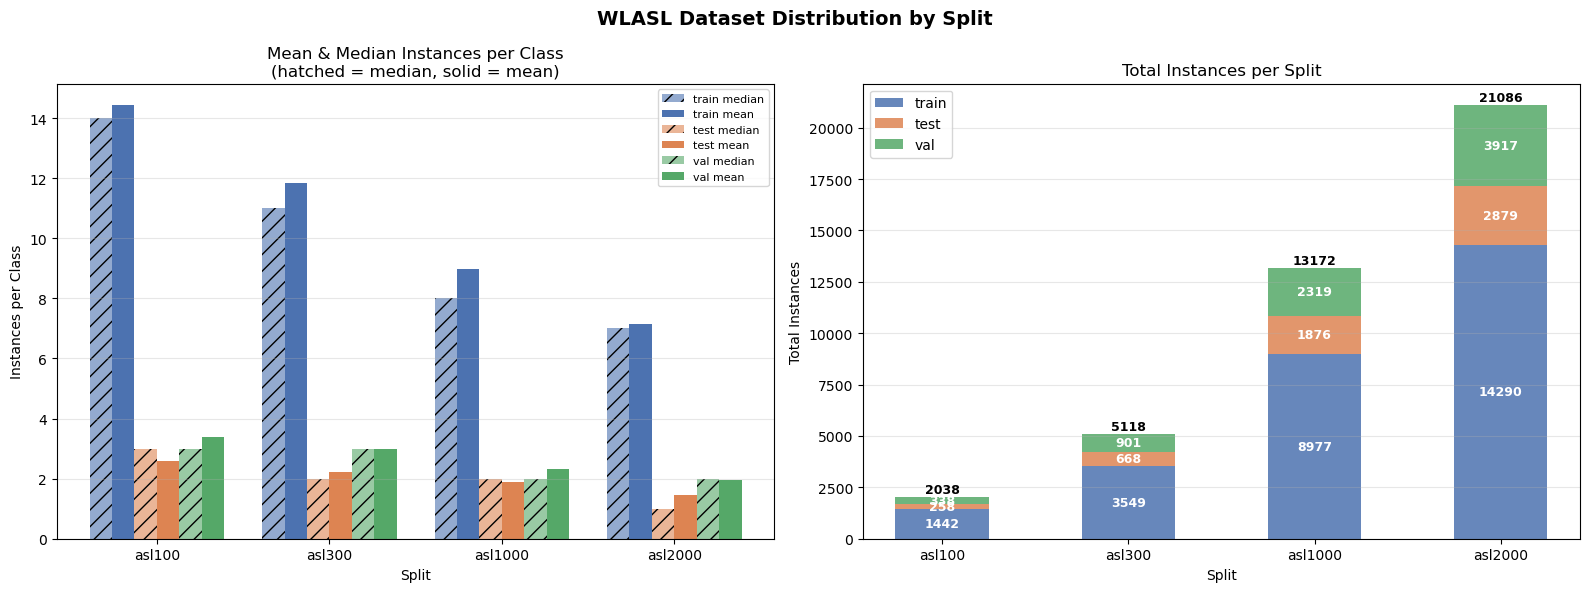

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

splits = list(split_dist.keys())
sets = ['train', 'test', 'val']
x = np.arange(len(splits))
width = 0.13
colors = {'train': '#4C72B0', 'test': '#DD8452', 'val': '#55A868'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("WLASL Dataset Distribution by Split", fontsize=14, fontweight='bold')

# --- Panel 1: Mean & Median instances per class ---
for i, set_name in enumerate(sets):
    medians = [split_dist[s][set_name]['median_num_inst'] for s in splits]
    means   = [split_dist[s][set_name]['mean_num_inst']   for s in splits]

    offset_med  = (i - 1) * 2 * width - width / 2
    offset_mean = (i - 1) * 2 * width + width / 2

    ax1.bar(x + offset_med,  medians, width, label=f'{set_name} median',
            color=colors[set_name], alpha=0.6, hatch='//')
    ax1.bar(x + offset_mean, means,   width, label=f'{set_name} mean',
            color=colors[set_name], alpha=1.0)

ax1.set_xticks(x)
ax1.set_xticklabels(splits)
ax1.set_xlabel("Split")
ax1.set_ylabel("Instances per Class")
ax1.set_title("Mean & Median Instances per Class\n(hatched = median, solid = mean)")
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# --- Panel 2: Total instances per split (stacked bar) ---
bottoms = np.zeros(len(splits))
for set_name in sets:
    totals = [split_dist[s][set_name]['total_num_inst'] for s in splits]
    bars = ax2.bar(x, totals, width=0.5, bottom=bottoms,
                   label=set_name, color=colors[set_name], alpha=0.85)
    # Label each segment
    for bar, val, bot in zip(bars, totals, bottoms):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bot + val / 2, str(val),
                 ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(totals)

# Total labels on top
for xi, bot in zip(x, bottoms):
    ax2.text(xi, bot + 50, str(int(bot)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(splits)
ax2.set_xlabel("Split")
ax2.set_ylabel("Total Instances")
ax2.set_title("Total Instances per Split")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("wlasl_distribution.png", dpi=150, bbox_inches='tight')
plt.show()